<div style="padding:22px; border-radius:14px; background:linear-gradient(135deg,#0f2027,#203a43,#2c5364); color:white; font-family:Segoe UI,Roboto,Arial; box-shadow:0 8px 22px rgba(0,0,0,0.25);">

<h1 style="margin-top:0;font-size:32px;">🫀 Heart Disease Prediction Dataset</h1>

<p style="font-size:16px;line-height:1.6;">
Cardiovascular disease remains the <b>leading cause of mortality worldwide</b>. This dataset captures a carefully curated
set of <b>demographic attributes, clinical measurements, exercise test results, and imaging findings</b> that collectively
enable predictive modeling of coronary artery disease.
</p>

<p style="font-size:15px;opacity:0.9;">
Each feature encodes a clinically meaningful signal related to cardiac function, vascular health, ischemic response,
or long-term atherosclerotic risk — forming a powerful foundation for exploratory analysis, machine learning modeling,
and explainable AI pipelines.
</p>

<div style="display:flex;gap:18px;margin-top:18px;flex-wrap:wrap;">
  <div style="flex:1;min-width:160px;background:rgba(255,255,255,0.08);padding:12px;border-radius:10px;">
    <b>🧬 Domain:</b><br>Clinical Cardiology
  </div>
  <div style="flex:1;min-width:160px;background:rgba(255,255,255,0.08);padding:12px;border-radius:10px;">
    <b>📊 Task:</b><br>Binary Classification
  </div>
  <div style="flex:1;min-width:160px;background:rgba(255,255,255,0.08);padding:12px;border-radius:10px;">
    <b>🎯 Target:</b><br>Heart Disease Presence
  </div>
</div>

</div>

## Introduction & Dataset Overview <a class = "anchor" id = "#introduction--dataset-overview"></a>

<details open>
<summary style="font-size:18px;font-weight:600;color:#38bdf8;">🧭 Click to Toggle Table of Contents</summary>

<ul style="line-height:1.9;font-size:15px;margin-top:12px;">
  <li><a href="#clinical-feature-taxonomy">🧠 Clinical Feature Taxonomy</a></li>
  <li><a href="#cardiovascular-disease-progression-pipeline">🩺 Disease Progression Pipeline</a></li>
  <li><a href="#machine-learning-framing">🤖 Machine Learning Framing</a></li>
  <li><a href="#model-development--training">⚙️ Model Development & Outputs</a></li>
  <li><a href="#model-evaluation--interpretability">📈 Model Evaluation & Explainability</a></li>
  <li><a href="#clinical-insights--conclusions">🏁 Clinical Insights & Conclusions</a></li>
</ul>

</details>

In [1]:
!pip install lazypredict h2o

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 61.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 66.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 45.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 808.4/808.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 10.9 MB/s eta 0:00:00


In [2]:
# Import libraries
import numpy as np 
import pandas as pd 
import os
from sklearn.model_selection import train_test_split
from lazypredict.Supervised import LazyClassifier, CLASSIFIERS
import h2o
from h2o.automl import H2OAutoML
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
import shap

In [3]:
# Get file information from folder
for dirname, _, filenames in os.walk('/kaggle/input'):

    for filename in filenames:
        
        print(os.path.join(dirname, filename))

/kaggle/input/playground-series-s6e2/sample_submission.csv
/kaggle/input/playground-series-s6e2/train.csv
/kaggle/input/playground-series-s6e2/test.csv


In [4]:
# Read the data
df = pd.read_csv('/kaggle/input/playground-series-s6e2/train.csv').drop('id', axis = 1)
test = pd.read_csv('/kaggle/input/playground-series-s6e2/test.csv') #.drop('id', axis = 1)

## 🧠 Clinical Feature Taxonomy

In [5]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.60,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.00,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.00,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.00,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.80,2,3,3,Presence


<div style="padding:20px;border-radius:14px;background:linear-gradient(135deg,#141e30,#243b55);color:white;font-family:Segoe UI;box-shadow:0 6px 18px rgba(0,0,0,0.25);">

<p style="font-size:15px;line-height:1.6;">
Each feature is derived from well-established cardiological diagnostics. Together they capture
multiple physiological dimensions of coronary artery disease:
</p>

<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(200px,1fr));gap:16px;margin-top:18px;">

  <div style="background:rgba(255,255,255,0.08);padding:14px;border-radius:12px;">
    <h4>🧓 Demographics</h4>
    <ul>
      <li>Age</li>
      <li>Sex</li>
    </ul>
  </div>

  <div style="background:rgba(255,255,255,0.08);padding:14px;border-radius:12px;">
    <h4>🧈 Metabolic Risk</h4>
    <ul>
      <li>Cholesterol</li>
      <li>Fasting Blood Sugar</li>
      <li>Blood Pressure</li>
    </ul>
  </div>

  <div style="background:rgba(255,255,255,0.08);padding:14px;border-radius:12px;">
    <h4>❤️ Symptom Profiles</h4>
    <ul>
      <li>Chest Pain Type</li>
      <li>Exercise-induced Angina</li>
    </ul>
  </div>

  <div style="background:rgba(255,255,255,0.08);padding:14px;border-radius:12px;">
    <h4>📈 Functional Testing</h4>
    <ul>
      <li>EKG Results</li>
      <li>ST Depression</li>
      <li>ST Slope</li>
      <li>Max Heart Rate</li>
    </ul>
  </div>

  <div style="background:rgba(255,255,255,0.08);padding:14px;border-radius:12px;">
    <h4>🩻 Imaging Diagnostics</h4>
    <ul>
      <li>Fluoroscopy Vessels</li>
      <li>Thallium Stress Test</li>
    </ul>
  </div>

</div>
</div>


Clinical & Predictive Rationale for Each Feature

This dataset is essentially a compact cardiovascular risk profiling system. Every variable reflects a known contributor to coronary artery disease (CAD) and myocardial ischemia.

---

🧓 Age — Physiological Risk Accumulation

Clinical significance:

Atherosclerosis is a progressive disease.

Arterial plaque accumulation increases over decades.

Risk of coronary artery disease increases sharply after:

45+ in men

55+ in women

Predictive value:

One of the strongest baseline predictors.

Often interacts strongly with:

cholesterol

BP

exercise tolerance

vessel occlusion

Model insight:

Typically nonlinear → tree models & splines outperform linear models.

---

🚹 Sex — Hormonal Protection & Risk Distribution

Clinical significance:

Estrogen provides vascular protection.

Men develop CAD ~7–10 years earlier than women.

Predictive role:

Important moderator variable.

Interacts with:

age

cholesterol

blood pressure

Limitations:

Binary encoding oversimplifies biological sex differences.

Doesn’t capture hormone therapy or menopause status.

---

💔 Chest Pain Type — Symptom Pattern Recognition
Type	Clinical Meaning
Typical angina	Classic ischemic pain — very strong predictor
Atypical angina	Moderate risk
Non-anginal	Low ischemic correlation
Asymptomatic	High danger — silent ischemia

Why powerful:

Encodes clinical intuition directly.

Strongest single variable in many models.

Predictive impact:

Very high.

Often dominates feature importance rankings.

---

💉 Blood Pressure — Vascular Load & Endothelial Stress

Clinical significance:

Chronic hypertension:

damages arterial walls

accelerates plaque formation

increases myocardial workload

Predictive role:

Strong long-term risk marker

Especially predictive when interacting with:

age

cholesterol

---

🧈 Cholesterol — Primary Atherosclerotic Driver

Clinical significance:

Elevated LDL → plaque formation → arterial narrowing.

One of the root causes of CAD.

Predictive role:

Directly tied to:

vessel occlusion

exercise ischemia

EKG changes

Limitations:

Single cholesterol measurement lacks:

HDL

LDL

triglycerides

Full lipid profile would greatly improve model accuracy.

---

🍬 Fasting Blood Sugar — Diabetic Cardiomyopathy Indicator

Clinical significance:

Diabetes is equivalent to coronary disease risk.

High glucose:

damages blood vessels

increases plaque instability

Predictive role:

Moderate standalone predictor.

Strong interaction effect with:

BP

cholesterol

obesity

---

📈 EKG Results — Electrical Evidence of Ischemia

Clinical meaning:

ST-T abnormalities → ischemia

LV hypertrophy → chronic pressure overload

Predictive value:

Very high.

Direct physiological evidence of cardiac stress.

Model importance:

Typically top 5 feature.

---

❤️ Max Heart Rate — Cardiorespiratory Fitness Proxy

Clinical meaning:

Lower max HR → poor cardiac reserve

Indicates:

compromised coronary flow

cardiac conditioning

Predictive role:

Strong inverse predictor:

Lower HR → higher disease risk

---

🏃 Exercise-Induced Angina — Provoked Ischemia Detection

Clinical meaning:

Pain during exertion = coronary artery obstruction.

Predictive strength:

Extremely high

Often one of the strongest model features.

---

📉 ST Depression — Quantified Ischemic Response

Clinical meaning:

Measures severity of myocardial ischemia during exercise.

Predictive role:

One of the most powerful numeric predictors

Correlates strongly with:

vessel occlusion

disease severity

---

⛰️ Slope of ST — Ischemia Recovery Dynamics

Clinical meaning:

Slope	Meaning
Upsloping	Normal
Flat	Suspicious
Downsloping	Strong ischemia

Predictive role:

Adds dynamic response characterization.

---


🩸 Number of Vessels (Fluoroscopy) — Anatomical Ground Truth

Clinical meaning:

Direct imaging of:

coronary obstruction severity

The closest proxy to angiography

Predictive role:

Among the strongest possible predictors

Nearly diagnostic on its own.

---

🧬 Thallium Stress Test — Perfusion Defect Detection

Clinical meaning:

Identifies:

reversible ischemia

infarcted tissue

Predictive role:

Extremely powerful

Represents functional blood flow impairment

---

🎯 Target Variable: Heart Disease

Represents angiographically or clinically diagnosed coronary artery disease, the gold standard outcome.

In [6]:
df.shape

(630000, 14)

In [7]:
df.dtypes

Age                          int64
Sex                          int64
Chest pain type              int64
BP                           int64
Cholesterol                  int64
FBS over 120                 int64
EKG results                  int64
Max HR                       int64
Exercise angina              int64
ST depression              float64
Slope of ST                  int64
Number of vessels fluro      int64
Thallium                     int64
Heart Disease               object
dtype: object

In [8]:
df.isnull().sum()

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [9]:
df['Heart Disease'].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

In [10]:
# Map the outcome to numeric
def convert_outcomes(outcome):

    if outcome == 'Absence':

        return 0

    elif outcome == 'Presence':

        return 1
        
df['Heart Disease'] = df['Heart Disease'].map(convert_outcomes)

In [11]:
# Split the data for training
x = df[[i for i in df.columns if i != 'Heart Disease']]
y = df['Heart Disease']

xtrain, xval, ytrain, yval = train_test_split(x, y, test_size = .2, random_state = 100)

## 🩺 Disease Progression Pipeline

<div style="padding:20px;border-radius:14px;background:linear-gradient(135deg,#0b486b,#f56217);color:white;font-family:Segoe UI;box-shadow:0 6px 18px rgba(0,0,0,0.25);">

<div style="display:flex;flex-wrap:wrap;gap:12px;margin-top:16px;">

  <div style="flex:1;min-width:180px;background:rgba(255,255,255,0.12);padding:12px;border-radius:10px;">
    🧈 <b>Metabolic Risk</b><br>
    Cholesterol • Glucose • BP
  </div>

  <div style="flex:1;min-width:180px;background:rgba(255,255,255,0.12);padding:12px;border-radius:10px;">
    🧬 <b>Atherosclerosis</b><br>
    Progressive plaque formation
  </div>

  <div style="flex:1;min-width:180px;background:rgba(255,255,255,0.12);padding:12px;border-radius:10px;">
    🩸 <b>Coronary Narrowing</b><br>
    Vessel occlusion (fluoroscopy)
  </div>

  <div style="flex:1;min-width:180px;background:rgba(255,255,255,0.12);padding:12px;border-radius:10px;">
    ❤️ <b>Ischemic Response</b><br>
    Angina • ST changes • Thallium defects
  </div>

  <div style="flex:1;min-width:180px;background:rgba(255,255,255,0.12);padding:12px;border-radius:10px;">
    🎯 <b>Clinical Outcome</b><br>
    Heart disease diagnosis
  </div>

</div>

</div>


## 🤖 Machine Learning Framing - H2O

In [12]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.17" 2025-10-21; OpenJDK Runtime Environment (build 17.0.17+10-Ubuntu-122.04); OpenJDK 64-Bit Server VM (build 17.0.17+10-Ubuntu-122.04, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmp_ftvky3k
  JVM stdout: /tmp/tmp_ftvky3k/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmp_ftvky3k/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,02 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.9
H2O_cluster_version_age:,2 months and 25 days
H2O_cluster_name:,H2O_from_python_unknownUser_haghlj
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,7.500 Gb
H2O_cluster_total_cores:,4
H2O_cluster_allowed_cores:,4
H2O_cluster_status:,"locked, healthy"


In [13]:
# Convert data for h2o
train_df = h2o.H2OFrame(df)


#train_df, val_df = loan_level.split_frame([0.8], seed=623)


test_df = h2o.H2OFrame(test.drop('id', axis = 1))

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [15]:
# Defining feature and label columns
X = train_df.columns
Y = 'Heart Disease'
X.remove(Y)

In [16]:
# Convert target to binary outcome
train_df[Y] = train_df[Y].asfactor()

In [17]:
# Call h20automl  function
aml = H2OAutoML(max_runtime_secs = 600,
                seed = 100,
                project_name ='heart_disease_model')

In [18]:
# Train model and record time % time
aml.train(x = X, y = Y, training_frame = train_df)

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


key,value
Stacking strategy,blending
Number of base models (used / total),13/25
# GBM base models (used / total),5/10
# XGBoost base models (used / total),6/9
# DeepLearning base models (used / total),2/3
# GLM base models (used / total),0/1
# DRF base models (used / total),0/2
Metalearner algorithm,GLM
Metalearner fold assignment scheme,AUTO
Metalearner nfolds,0


In [20]:
# Isolatre top performing model
leader_model = aml.leader

In [21]:
leader_model

key,value
Stacking strategy,blending
Number of base models (used / total),13/25
# GBM base models (used / total),5/10
# XGBoost base models (used / total),6/9
# DeepLearning base models (used / total),2/3
# GLM base models (used / total),0/1
# DRF base models (used / total),0/2
Metalearner algorithm,GLM
Metalearner fold assignment scheme,AUTO
Metalearner nfolds,0


## 🤖 Machine Learning Framing - LazyClassifier

In [ ]:
# Filter models that have high memory usage
#highmem_classifiers = ["LabelSpreading", "LabelPropagation", "BernoulliNB", "KNeighborsClassifier", "HistGradientBoostingClassifier"]
#classifiers = [c for c in CLASSIFIERS if c[0] not in highmem_classifiers]

In [ ]:
# Init learning ensemble
#clf = LazyClassifier(classifiers = classifiers, verbose = 0, ignore_warnings = False, custom_metric = None)

In [ ]:
#%time models, predictions = clf.fit(xtrain, xval, ytrain, yval)

In [ ]:
#print(models)

## ⚙️ Model Development & Outputs

In [22]:
test_df.head()

Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
58,1,3,120,288,0,2,145,1,0.8,2,3,3
55,0,2,120,209,0,0,172,0,0,1,0,3
54,1,4,120,268,0,0,150,1,0,2,3,7
44,0,3,112,177,0,0,168,0,0.9,1,0,3
43,1,1,138,267,0,0,163,0,1.8,2,0,7
61,1,4,130,254,0,2,139,1,1.4,2,0,7
48,0,2,120,330,0,2,166,0,0,1,1,3
57,1,4,142,282,0,0,153,0,0,1,0,7
60,1,4,130,249,0,2,131,1,0.4,2,1,7
43,0,3,120,250,0,2,160,0,0.9,1,0,3


In [23]:
# Use H2O leader model to gnerate predictions
predictions = leader_model.predict(test_df)

stackedensemble prediction progress: |███████████████████████████████████████████| (done) 100%


In [24]:
predictions_pd = predictions.as_data_frame()

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


In [25]:
predictions_pd.head()

,predict,p0,p1
0,1,0.05,0.95
1,0,0.99,0.01
2,1,0.02,0.98
3,0,0.99,0.01
4,0,0.83,0.17


In [27]:
# Transfer preds to original dataset for kaggle submission
test['Heart Disease'] = predictions_pd['predict']

In [28]:
test.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,630000,58,1,3,120,288,0,2,145,1,0.80,2,3,3,1
1,630001,55,0,2,120,209,0,0,172,0,0.00,1,0,3,0
2,630002,54,1,4,120,268,0,0,150,1,0.00,2,3,7,1
3,630003,44,0,3,112,177,0,0,168,0,0.90,1,0,3,0
4,630004,43,1,1,138,267,0,0,163,0,1.80,2,0,7,0


In [32]:
# Write to file
test[['id', 'Heart Disease']].to_csv('heart_disease_test_h2o.csv', index = False)

In [33]:
!kaggle competitions submit -c playground-series-s6e2 -f heart_disease_test_h2o.csv -m "h2o heart disease predictions test set"

100%|██████████████████████████████████████| 2.32M/2.32M [00:01<00:00, 1.32MB/s]
Successfully submitted to Predicting Heart Disease

In [35]:
!kaggle competitions submissions -c playground-series-s6e2

fileName                         date                        description                                  status                     publicScore  privateScore  
-------------------------------  --------------------------  -------------------------------------------  -------------------------  -----------  ------------  
heart_disease_test_h2o.csv       2026-02-19 16:37:17.767000  h2o heart disease predictions test set       SubmissionStatus.COMPLETE  0.88407                    
heart_disease_test_h2o.csv       2026-02-19 15:41:44.227000  h2o heart disease predictions test set       SubmissionStatus.COMPLETE  0.88458                    
heart_disease_test_gbm.csv       2026-02-18 17:32:39.860000  LightGBM heart disease predictions test set  SubmissionStatus.COMPLETE  0.95238                    
heart_disease_test_catboost.csv  2026-02-18 17:26:48.153000  catboost heart disease predictions test set  SubmissionStatus.COMPLETE  0.88391                    
heart_disease_test_xgb.csv       2

## 📈 Model Evaluation & Explainability

Here we will rebuild the LightGBM model to get feature-specific insights

In [36]:
# Using LightGBM
dtrain = lgb.Dataset(xtrain, label = ytrain)

gbm = lgb.train({'lambda_l1': 0.015039588516392215, 
                 'lambda_l2': 0.009310257792019926, 
                 'num_leaves': 203, 
                 'feature_fraction': 0.40072973435009795, 
                 'bagging_fraction': 0.7294221380679635, 
                 'bagging_freq': 1, 
                 'min_child_samples': 85,
                 'seed': 100}, dtrain)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.045698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] Start training from score 0.448486
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


In [38]:
xval = xval.drop('Heart Disease', axis = 1)

In [39]:
gbmval = gbm.predict(xval)

xval['Heart Disease'] = gbmval
xval['Heart Disease'] = np.rint(xval['Heart Disease'])

In [40]:
print(f"LightGBM performance on Validation Data: {round(roc_auc_score(yval, xval['Heart Disease']), 4)}")

LightGBM performance on Validation Data: 0.8862


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

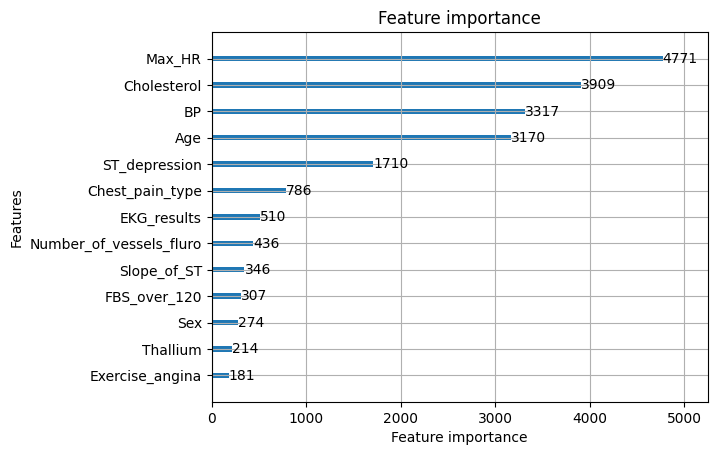

In [43]:
# Get scores from the mode
lgb.plot_importance(gbm)

## 🏁 Clinical Insights & Conclusions